In [1]:
#bibliotecas
!pip install -q torch_snippets #biblioteca Pytorch Snippets
from torch_snippets import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_dataset = datasets.MNIST(root='MNIST/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='MNIST/', train=False, transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.6 MB/s eta 0:00:00


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 331kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.91MB/s]


In [2]:
train_dataset[0][0]

tensor[1, 28, 28] n=784 (3.06 KiB) x∈[0. |█▁▁▁▁▁▁▁▁▁| 1.000] μ=0.138 σ=0.313

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder network
        #redes de codificação
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1) # camadas convoluicionais
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 256) # duas camadas totalmente conectadas
        self.fc21 = nn.Linear(256, 20) # mu
        self.fc22 = nn.Linear(256, 20) # logvar

        #Decoder network
        # redes de decodificação, onde ela gerara uma nova imagem, realizando uma série de operações na direção inversa
        self.fc3 = nn.Linear(20, 256)
        self.fc4 = nn.Linear(256, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        mu = self.fc21(x)
        logvar = self.fc22(x)
        return mu, logvar
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = Variable(torch.randn(std.size()).to(device))
            return eps.mul(std).add_(mu)
        else:
            return mu
    def decode(self, z):
        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))
        z = z.view(z.size(0), 64, 7, 7)
        z = F.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z = self.decode(z)
        return z, mu, logvar

In [5]:
# class VAE(nn.Module):
#   def _init__(self, x_dim, h_dim1, h_dim2, z_dim):
#     super(VAE, self).__init__()
#     self.d1 = nn.Linear(x_dim, h_dim1)
#     self.d2 = nn.Linear(h_dimi, h_dim2)
#     self.d31 = nn. Linear(h_dim2, z_dim)
#     self.d32 = nn. Linear(h_dim2, z_dim)
#     self.d4 = nn.Linear(z_dim, h_dim2)
#     self.d5 = nn.Linear(h_dim2, h_dim1)
#     self.d6 = nn.Linear(h_dimi, x_dim)
#   def encoder(self, x):
#     h = F.relu(self.d1(x))
#     h = F.relu(self.d2(h))
#     return self.d31(h), self.d32(h)
#   def sampling(self, mean, log_var):
#     std = torch.exp(0.5*log_var)
#     eps = torch.randn_like(std)
#     return eps.mul(std).add_(mean)
#   def decoder(self, z):
#     h = F.relu(self.d4(z))
#     h = F.relu(self.d5(h))
#     return F.sigmoid(self.d6(h))
#   def forward(self, x):
#     mean, log_var = self.encoder(x.view(-1, 784))
#     z= self.sampling (mean, log_var)
#     return self.decoder(z), mean, log_var

In [6]:
# função de treinar e validar o VAE
def train_batch(data,model,optimizer,loss_function):
    model.train()
    data = data.to(device)
    optimizer.zero_grad()
    recon_batch, mean, log_var = model(data)
    # calculando a perda em um lote de imagens
    loss,mse,kld = loss_function(recon_batch, data, mean, log_var)
    loss.backward()
    optimizer.step()
    return loss, mse, kld, log_var.mean(), mean.mean()


@torch.no_grad()
def validate_batch(data,model,loss_function): # faz a validação de um lote
    model.eval()
    data = data.to(device)
    recon,mean,log_var = model(data)
    loss, mse, kld = loss_function(recon,data,mean,log_var)
    return loss, mse, kld, log_var.mean(), mean.mean()

In [7]:
def loss_function(recon_x, x, mean, log_var):
    RECON = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1+log_var-mean.pow(2) - log_var.exp())
    return RECON + KLD, RECON, KLD

EPOCH: 1.000  train_mean: 0.000  train_loss: 2725.142  train_log_var: -0.584  val_mean: -0.013  train_recon: 2323.959  val_kld: 604.192  val_loss: 1853.349  val_recon: 1249.157  val_log_var: -0.915  train_kld: 401.183  (80.90s - 728.09s remaining)


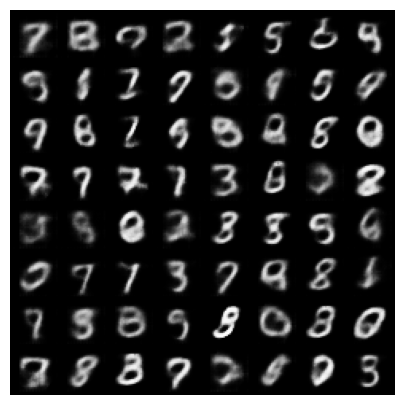

EPOCH: 2.000  train_mean: 0.001  train_loss: 2040.660  train_log_var: -0.995  val_mean: -0.012  train_recon: 1398.080  val_kld: 639.960  val_loss: 1652.498  val_recon: 1012.538  val_log_var: -1.011  train_kld: 642.580  (170.04s - 680.18s remaining)


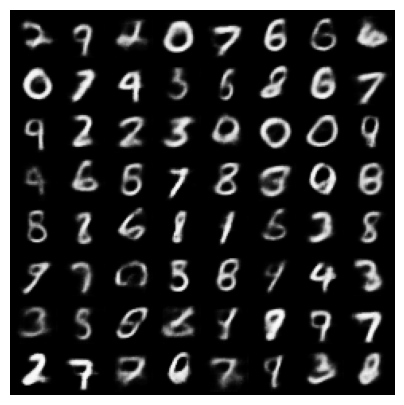

EPOCH: 3.000  train_mean: -0.001  train_loss: 1944.431  train_log_var: -1.064  val_mean: 0.005  train_recon: 1261.242  val_kld: 705.783  val_loss: 1626.332  val_recon: 920.549  val_log_var: -1.103  train_kld: 683.190  (262.20s - 611.80s remaining)


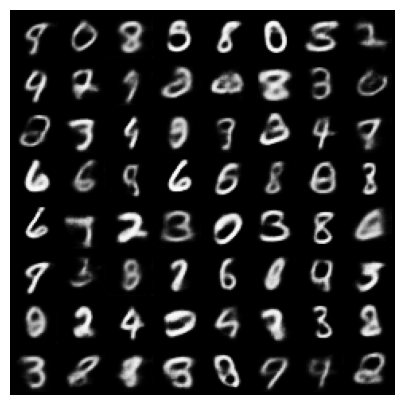

EPOCH: 4.000  train_mean: -0.000  train_loss: 1893.820  train_log_var: -1.103  val_mean: 0.003  train_recon: 1186.817  val_kld: 744.253  val_loss: 1607.507  val_recon: 863.254  val_log_var: -1.154  train_kld: 707.003  (351.85s - 527.77s remaining)


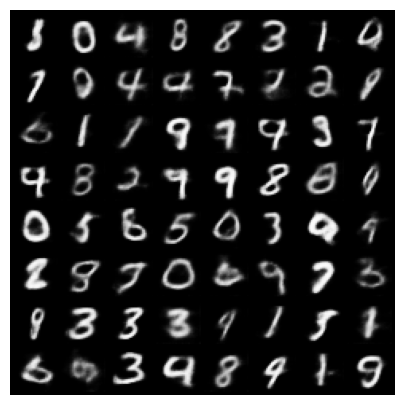

EPOCH: 5.000  train_mean: -0.000  train_loss: 1861.915  train_log_var: -1.121  val_mean: 0.007  train_recon: 1143.687  val_kld: 730.547  val_loss: 1559.237  val_recon: 828.690  val_log_var: -1.152  train_kld: 718.228  (440.89s - 440.89s remaining)


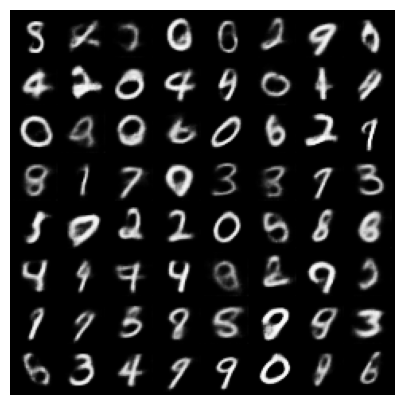

EPOCH: 6.000  train_mean: -0.001  train_loss: 1838.775  train_log_var: -1.135  val_mean: -0.001  train_recon: 1112.496  val_kld: 724.515  val_loss: 1524.484  val_recon: 799.969  val_log_var: -1.146  train_kld: 726.280  (526.65s - 351.10s remaining)


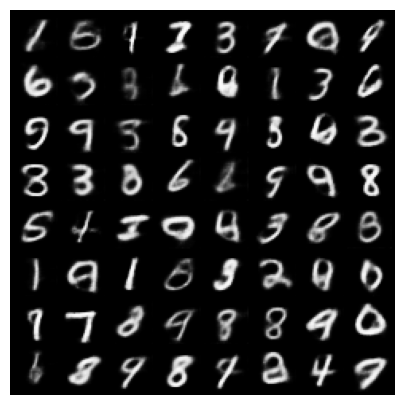

EPOCH: 7.000  train_mean: -0.001  train_loss: 1822.767  train_log_var: -1.149  val_mean: -0.008  train_recon: 1087.372  val_kld: 755.079  val_loss: 1536.541  val_recon: 781.462  val_log_var: -1.172  train_kld: 735.395  (612.54s - 262.52s remaining)


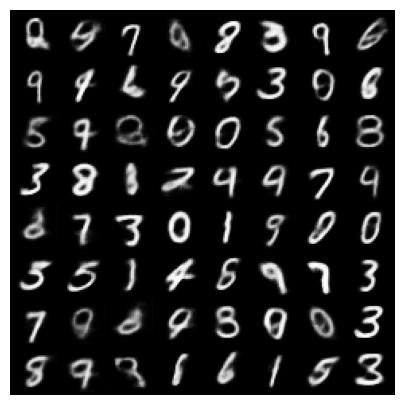

EPOCH: 8.000  train_mean: -0.001  train_loss: 1808.043  train_log_var: -1.157  val_mean: -0.017  train_recon: 1067.778  val_kld: 718.436  val_loss: 1481.710  val_recon: 763.274  val_log_var: -1.142  train_kld: 740.265  (697.61s - 174.40s remaining)


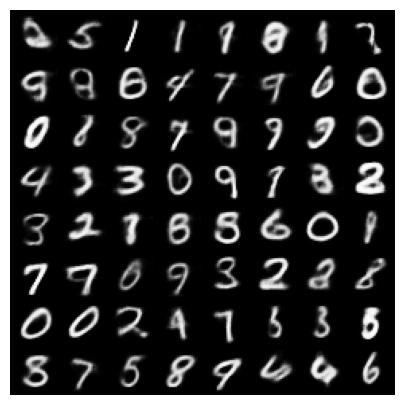

EPOCH: 9.000  train_mean: -0.001  train_loss: 1797.785  train_log_var: -1.164  val_mean: -0.020  train_recon: 1053.082  val_kld: 754.322  val_loss: 1503.579  val_recon: 749.257  val_log_var: -1.168  train_kld: 744.703  (791.75s - 87.97s remaining)


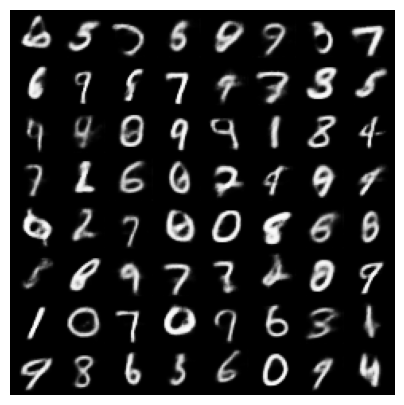

EPOCH: 10.000  train_mean: -0.001  train_loss: 1786.990  train_log_var: -1.168  val_mean: 0.012  train_recon: 1038.881  val_kld: 760.587  val_loss: 1494.530  val_recon: 733.943  val_log_var: -1.189  train_kld: 748.109  (879.83s - 0.00s remaining)


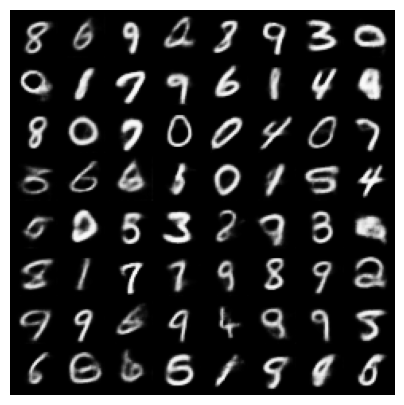

In [8]:
# conjunto de dados para 10 epochs
n_epochs = 10
log = Report(n_epochs)
vae = VAE().to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

# para cada época é calculado a perda em um lote de imagem do conjunto de treinamento
for epoch in range(n_epochs):
    N = len(train_loader)
    for batch_idx, (data, _) in enumerate(train_loader):
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r')

    N = len(test_loader)
    for batch_idx, (data, _) in enumerate(test_loader):
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r')

    log.report_avgs(epoch+1)
    with torch.no_grad():
        z = torch.randn(64, 20).to(device)
        sample = vae.decode(z).to(device)
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
        show(images)